# Leverage

**Leverage** is the strategic use of **borrowed money (debt)** to increase the size of an investment or project beyond what you could achieve with your own capital alone. In simple terms, you use a small amount of *your money* to control a much larger amount of *total money*, amplifying both potential **gains** and **losses**. Leverage is one of the most powerful (and dangerous) tools in finance, investing, business, and even physics. In this notebook we focus primarily on **financial leverage**, the version you’ll encounter most often in investing and corporate finance.

#### How Leverage Works

The core idea is, you combine two sources of capital:
- **Equity** = your own money
- **Debt** = money you borrow

The **leverage ratio** tells you how much debt you’re using:

| Scenario                     | Cash Purchase (No Leverage) | Leveraged Purchase (80% Loan) |
|------------------------------|-----------------------------|-------------------------------|
| House price                  | $200,000                    | $200,000                      |
| Your money (down payment)    | $200,000                    | $40,000                       |
| Loan amount                  | $0                          | $160,000                      |
| House value rises 10%        | New value = $220,000        | New value = $220,000          |
| Your new equity              | $220,000                    | $220,000 – $160,000 = **$60,000** |
| Profit                       | $20,000                     | $20,000                       |
| **Return on your money**     | **10%**                     | **50%**                       |

The same $20,000 price increase gave you **5× more return** on your capital because you only put up 20% of the purchase price.

If the house instead fell 10% to $180,000:
- Cash buyer: –10% loss
- Leveraged buyer: equity drops to $20,000 → **–50% loss** on your $40k

**Leverage amplifies percentage returns in both directions.**

**Stock Market Example (Margin Trading)**

You have $10,000 and your broker offers **5:1 leverage** (common in many markets).
- You can buy **$50,000** worth of stock.
- Stock rises 8% → position becomes $54,000.
- After repaying the $40,000 borrowed (ignore interest for simplicity): you keep $14,000.
- Return on your $10k: **+40%** instead of +8%.

#### How do I use leverage?

You are specifically interested in **trading on margin** and **margin in algorithmic trading**. **Trading on margin** is a type of leverage. It involves taking out a loan from your broker and adding it to your capital base in order to increase the returns of your trading strategy. Since you are borrowing money to invest, you ideally only want to trade on margin when your expected returns from the strategy are **greater than the interest** you pay on the borrowed funds. If the returns would not exceed the interest + your current capital's opportunity cost, you may not want to execute the trade.

Each broker checks your account and authorizes different levels of margin (borrowing power) depending on:
- your broker,
- account size,
- risk of strategies,
- and other factors.

If you have a profitable strategy, using leverage can **significantly increase** the amount of money you make overall by amplifying the capital you are working with. The involvement of the broker's automatic borrowing is an important factor to consider when constructing **algorithmic trading strategies**, because the broker will usually borrow automatically as needed when your strategy wants to open a larger position. This means your leverage strategy can sometimes take on **more leverage than you are comfortable with**. You may want to explicitly limit how much leverage your algorithm can take so that you are not borrowing at ratios you consider too risky.

#### Measuring Current Leverage

We measure the current leverage of a portfolio by examining the **leverage ratio**. The leverage ratio of an algorithm/strategy is calculated as:

$$
\text{Leverage Ratio} = \frac{\text{Debt} + \text{Capital Base}}{\text{Capital Base}}
$$

(or equivalently: 1 + Debt / Capital Base). We limit the amount of leverage that our strategy uses by capping this leverage ratio.

Import the necessary libraries

In [42]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

from matplotlib import pyplot as plt
from __future__ import division

warnings.filterwarnings('ignore')

#### Simple Single-Period Example

In [43]:
capital = 100000
r_p = 0.05 # Aggregate performance of assets in the portfolio
r_no_lvg = capital * r_p

print("Portfolio returns without leverage: ${:.2f}".format(r_no_lvg))

Portfolio returns without leverage: $5000.00


The above illustrates the portfolio returns without leverage. Let us now add some debt, leveraging the portfolio and see how the returns change.

In [44]:
debt = 100000

r_lvg = (capital + debt) * r_p
r_lvg_pct = r_lvg / capital

# Returns are calculated over the initial capital base. You can think of debt as an asset purchased and added to the portfolio
lvg_ratio = (debt + capital) / capital

print("Portfolio returns with leverage: ${:.2f}".format(r_lvg))
print("Percentage returns with {}x leverage ratio: {:.2f}".format(lvg_ratio, r_lvg_pct))


Portfolio returns with leverage: $10000.00
Percentage returns with 2.0x leverage ratio: 0.10


The above is the ideal situation. Suppose now you are charged a fee or interest in taking the loan to invest. As shown below, we shall consider the effects of an interest payment in our one-period model.

In [45]:
capital = 100000
debt = 50000
i = 0.02
r_p = 0.05

int_payment = debt * i
r_lvg = (capital + debt) * r_p
r_total = r_lvg - int_payment
r_total_pct = r_total / capital
lvg_ratio = (debt + capital) / capital

print("Portfolio returns with leverage and interests: ${:.2f}".format(r_total))
print("Percentage returns with {}x leverage ratio and {:.2f}% interest: {:.2f}%".format(lvg_ratio, i * 100, r_total_pct * 100))

Portfolio returns with leverage and interests: $6500.00
Percentage returns with 1.5x leverage ratio and 2.00% interest: 6.50%


That makes a lot more sense. It would be unreasonable to assume that we can add someone else's money to our portfolio without our returns being at least as high as they were in the unlevered portfolio with no interest. By using leverage, we benefit from levering a portfolio only as long as we have a reliable strategy that can make sufficient returns to offset the cost of debt.

Our additive returns have increased over our unlevered strategy, but overall we are gaining a lower percentage return. This is not entirely a bad thing — as we manage a larger amount of money to trade on, we are able to add more of our profits back to the portfolio. However, if we are not careful, we could potentially end up spending all of our profits trying to pay off the interest that we accrued in the first place.

This single-period model is only a small piece of the story. Loans are rarely, if ever, paid off in one period. Payments are spread out over the life of a loan, ensuring that you do not simply get the money for free. In this context, to properly earn a profit using leverage, we obviously do not simply have to be making more money than we are paying out.


#### How do I get leverage?

Despite interest payments and additional fees. When trading with leverage, or on margin, these naturally borrowed money to do anything we incur loans from our broker. Brokers are loathe to part with their cash without a good reason. Using leverage, or high volatility strategies, can be dangerous unless you have a high tolerance for risk. Even if you lose money, you will still have to pay the broker back.

#### Leverage in an Algorithm

Leverage becomes significantly more complicated when we are dealing with an **algorithm**. Every time an algorithm rebalances its portfolio or makes a trade, there is a possibility of affecting the **leverage ratio**.
- If there isn't enough cash on hand to cover its positions, it will need to **borrow more** → increasing the leverage ratio  
- In the same vein, it may utilize overall less cash for the next set of trades → **decreasing** the leverage ratio

#### RSI Crossover Strategy on MSFT (2010–2015) – Leverage Fluctuation Example

**Strategy rules** (simple and common for tutorials):
- RSI(14)
- **Long (+1)** when RSI crosses **above 30** (oversold → buy)
- **Short (-1)** when RSI crosses **below 70** (overbought → short)
- Hold the position until the opposite signal appears
- **Target leverage = 2.0×** (gross exposure = 2 × equity)
- **Rebalance only quarterly** (adjust position size + debt on the last trading day of each quarter)
- **2% annual interest** charged daily only on positive debt (borrowed cash for long positions)
- Between rebalances the position size (gross exposure) and debt stay fixed → **leverage drifts** with daily P&L + interest

[*********************100%***********************]  1 of 1 completed


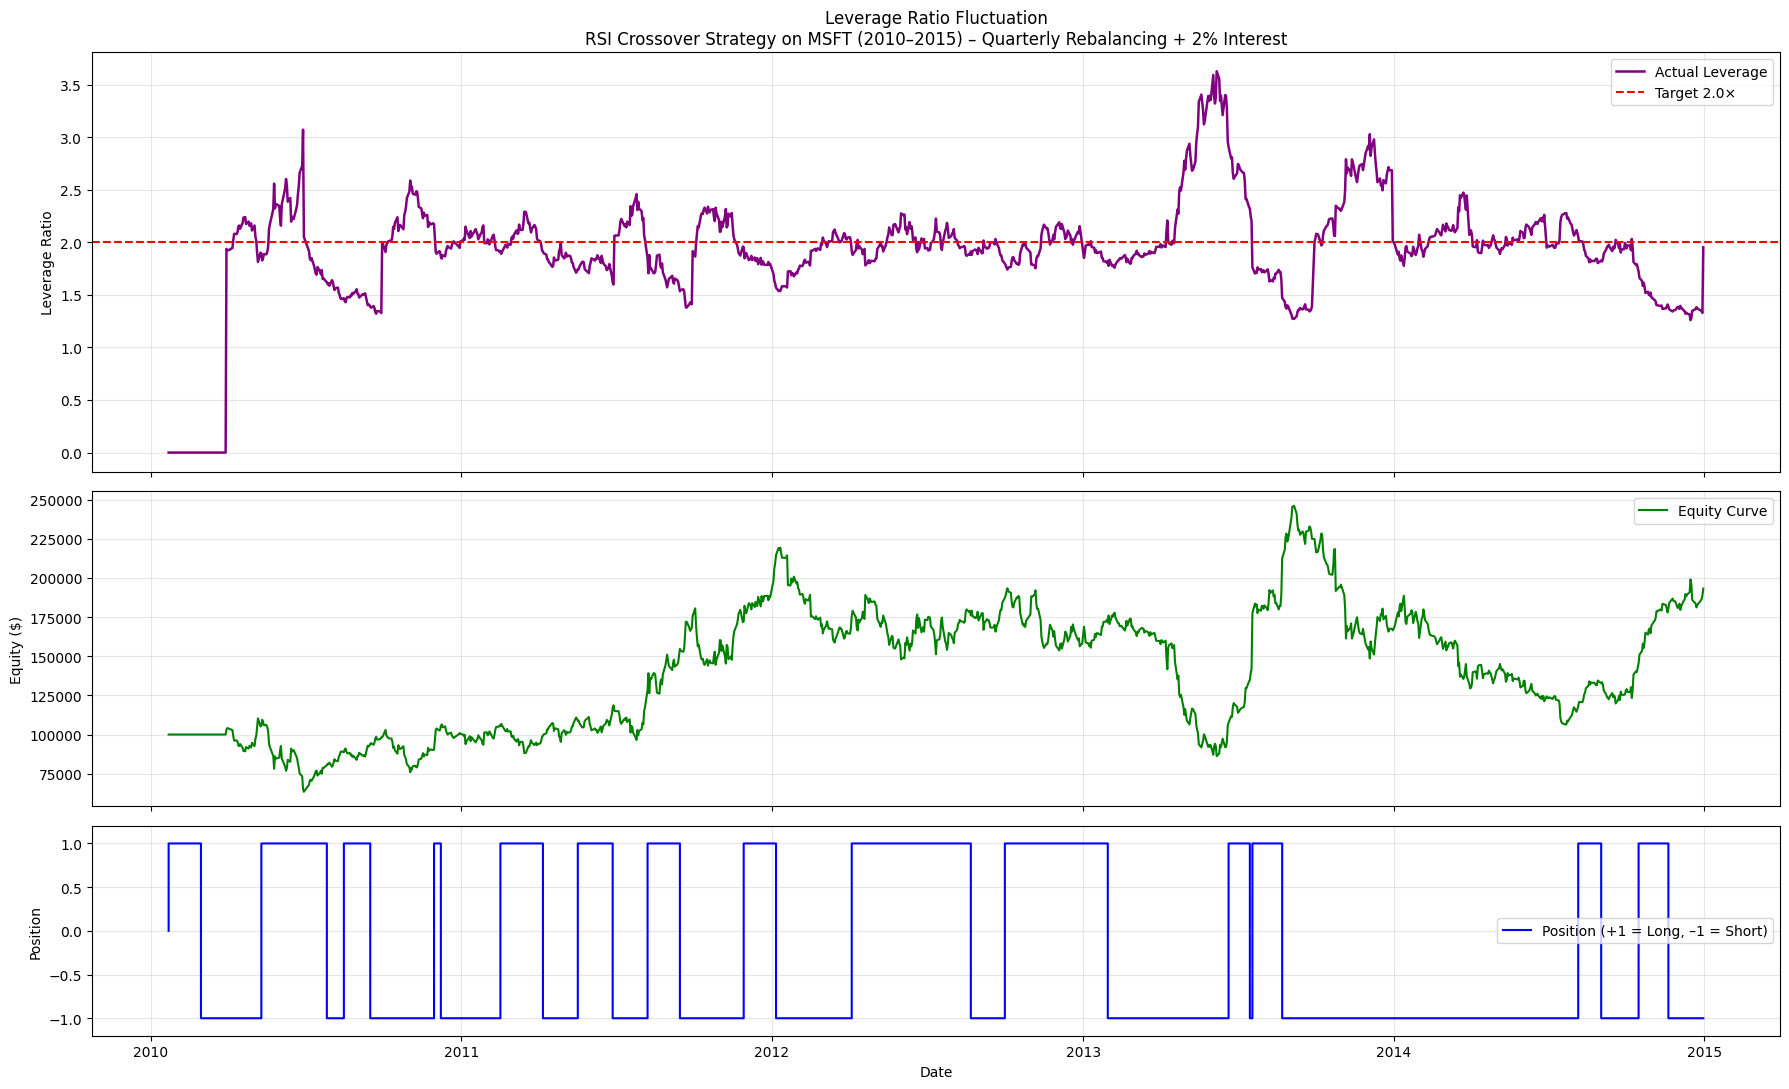

In [46]:
# Parameters initialization
stock_ticker = 'MSFT'
start_date = '2010-01-01'
end_date = '2015-01-01'

initial_equity = 100_000.0
target_leverage = 2.0
annual_interest = 0.02
daily_interest = annual_interest / 365.25

def format_dataframe_from_yfinance(df, ticker):
  new_df = pd.DataFrame()
  for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    new_df[col] = df[col][ticker]
  new_df.index.name = 'Date'
  new_df.columns = [''.join(col).strip() for col in new_df.columns]
  return new_df

price = format_dataframe_from_yfinance(yf.download(stock_ticker, start=start_date, end=end_date), stock_ticker)
price['return'] = price['Close'].pct_change()

# Define rsi function
def compute_rsi(price, window=14):
  delta = price.diff()
  gain = delta.where(delta > 0, 0).rolling(window=window).mean()
  loss = -delta.where(delta < 0, 0).rolling(window=window).mean()
  rs = gain / loss
  return 100 - (100 / (1 + rs))

price['rsi'] = compute_rsi(price['Close'])

# Generate the trading signal based on RSI
price['signal'] = 0
price.loc[(price['rsi'] > 30) & (price['rsi'].shift(1) <= 30), 'signal'] = 1
price.loc[(price['rsi'] < 70) & (price['rsi'].shift(1) >= 70), 'signal'] = -1
price['position'] = price['signal'].replace(0, np.nan).ffill().fillna(0)
price = price.dropna()

price
# Quarterly rebalance dates = last trading day of each quarter
rebalance_dates = price.resample('QE').last().index

# Run the simulation
equity = initial_equity
gross_exposure = 0.0
debt = 0.0

equity_history = []
leverage_history = []
date_history = []
position_history = []

for current_date in price.index:
  row = price.loc[current_date]
  daily_ret = row['return']
  current_position = row['position']          # direction can change any day

  # Rebalance size/debt only on quarterly dates (or first day)
  if current_date in rebalance_dates or len(equity_history) == 0:
    if current_position != 0:
      target_gross = target_leverage * equity
      if current_position > 0:   # Long
        gross_exposure = target_gross
        debt = gross_exposure - equity
      else:                      # Short
        gross_exposure = target_gross
        debt = equity - gross_exposure   # negative = cash from short sale
    else:
      gross_exposure = 0.0
      debt = 0.0

  # Daily P&L using current direction on fixed gross exposure
  daily_pnl = current_position * daily_ret * gross_exposure if gross_exposure > 0 else 0.0

  # Interest only on borrowed money (positive debt)
  interest_cost = max(debt, 0) * daily_interest

  # Update equity
  equity += daily_pnl - interest_cost

  # Current leverage (gross exposure / equity)
  current_leverage = abs(gross_exposure) / equity if equity > 0 else 0.0

  # Store
  equity_history.append(equity)
  leverage_history.append(current_leverage)
  date_history.append(current_date)
  position_history.append(current_position)
  
# Create a DataFrame for results
results = pd.DataFrame({
  'Equity': equity_history,
  'Leverage': leverage_history,
  'Position': position_history
}, index=date_history)

# Plot the leverage ratio over time
fig, axs = plt.subplots(3, 1, figsize=(18, 11), sharex=True, height_ratios=[2, 1.5, 1])

axs[0].plot(results.index, results['Leverage'], color='purple', linewidth=1.8, label='Actual Leverage')
axs[0].axhline(y=target_leverage, color='red', linestyle='--', linewidth=1.5, label=f'Target {target_leverage}×')
axs[0].set_title('Leverage Ratio Fluctuation\nRSI Crossover Strategy on MSFT (2010–2015) – Quarterly Rebalancing + 2% Interest')
axs[0].set_ylabel('Leverage Ratio')
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(results.index, results['Equity'], color='green', label='Equity Curve')
axs[1].set_ylabel('Equity ($)')
axs[1].legend()
axs[1].grid(alpha=0.3)

axs[2].step(results.index, results['Position'], color='blue', label='Position (+1 = Long, –1 = Short)')
axs[2].set_ylabel('Position')
axs[2].set_ylim(-1.2, 1.2)
axs[2].legend()
axs[2].grid(alpha=0.3)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

#### Risk-Adjusted Returns

Comparing returns of different investment opportunities without taking risk into account is meaningless. Some return streams may be higher than others, but this may be due to higher risks taken rather than any merit in the strategy itself. When judging strategies, we should adjust returns for the amount of risk taken. This allows us to compare strategies on an equal footing, independent of the risk level. It helps us effectively compare and determine which return streams are best for a given desired risk profile. One of the most prominent risk-adjusted measures is the **Sharpe Ratio**, defined as follows:

$$
\text{Sharpe Ratio} = \frac{r_p - r_f}{\sigma_p}
$$

Where:
- $r_p$ = expected portfolio return
- $r_f$ = risk-free rate
- $\sigma_p$ = standard deviation of portfolio returns (volatility)

The Sharpe Ratio essentially normalizes the returns of a portfolio, giving us a metric we can use as a measure of quality relative to other return streams. A **higher Sharpe Ratio** indicates that you are getting more return relative to the risk that your strategy is taking on.

#### Compare Strategies by Sharpe Ratio and then Lever Needed

In general, when you want to compare Sharpe Ratios of two strategies you may be interested in, you can think about how much leverage to apply to bring them to the same risk level (or desired risk level).

Assuming constraints like capital capacity don't kick in, you can:
- Pick the strategy with the better Sharpe Ratio
- Use leverage to multiply the Sharpe Ratio up to where you want it

Leverage allows you to add more money through borrowing and bring a low-return / low-risk strategy (e.g., 2% per year) up to a higher-return level (e.g., 10% per year) while maintaining roughly the same Sharpe Ratio. Alternatively, if a strategy has very high expected returns but you find the risk level too high (e.g., 20% per year returns but unacceptable volatility), you can deleverage by investing only a fraction of your available capital to bring the risk and returns down to acceptable levels.

In [53]:
# Strategy parameters
strat_A_ann_return = 0.22
strat_A_ann_vol    = 0.15
strat_B_ann_return = 0.105     # appears as 0.105 in image (likely typo in original as 0.ps)
strat_B_ann_vol    = 0.082     # appears as 0.0s → interpreted as 0.082
risk_free_rate     = 0.02
leverage = 3.0

# Sharpe Ratios (unlevered)
sharpe_A = (strat_A_ann_return - risk_free_rate) / strat_A_ann_vol
sharpe_B = (strat_B_ann_return - risk_free_rate) / strat_B_ann_vol

print(f"Strategy A Sharpe: {sharpe_A:.3f}")
print(f"Strategy B Sharpe: {sharpe_B:.3f}")
print(f"Strategy A Annual Return: {strat_A_ann_return:.3%}")
print(f"Strategy B Annual Return: {strat_B_ann_return:.3%}")

print(f"\nAdding {leverage}× leverage to Strategy B...\n")

# Levered returns and volatility (linear scaling)
levered_return = strat_B_ann_return * leverage - risk_free_rate * (leverage - 1)
levered_vol    = strat_B_ann_vol * leverage

# Levered Sharpe (should be very close to original B Sharpe under this model)
levered_sharpe = (levered_return - risk_free_rate) / levered_vol

print(f"Strategy B Levered Sharpe: {levered_sharpe:.3f}")
print(f"Strategy B Levered Annual Return: {levered_return:.3%}")
print(f"Strategy B Levered Annual Volatility: {levered_vol:.3%}")

Strategy A Sharpe: 1.333
Strategy B Sharpe: 1.037
Strategy A Annual Return: 22.000%
Strategy B Annual Return: 10.500%

Adding 3.0× leverage to Strategy B...

Strategy B Levered Sharpe: 1.037
Strategy B Levered Annual Return: 27.500%
Strategy B Levered Annual Volatility: 24.600%
